In [1]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import diffusion_maps as dmaps
import stats
import time

np.random.seed(42)

import importlib
importlib.reload(op_calc)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


<module 'operator_calculations' from '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/./utils/operator_calculations.py'>

In [2]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_zebrafish/'

In [3]:
condition_labels = ['Light (5x5cm)','Looming(5x5cm)','Dark_Transitions(5x5cm)','Dark (5x5cm)','3 min Light<->Dark(5x5cm)',
                    'Light (1x5cm)','Phototaxis','Optomotor Response (1x5cm)','Optokinetic Response (5x5cm)',
                    'Prey Capture Param. (2.5x2.5cm)','Prey Capture Param. RW. (2.5x2.5cm)',
                    'Prey Capture Rot.(2.5x2.5cm)','Prey capture Rot. RW. (2.5x2.5cm)','Light RW. (2.5x2.5cm)']

condition_recs = np.array([[453,463],[49,109],[22,49],[443,453],[0,22],
                           [121,133],[163,193],[109,121],[133,164],
                           [193,258],[304,387],[258,273],[273,304],
                           [387,443]])

In [4]:
conditions = np.zeros((np.max(condition_recs),2),dtype='object')
for k in range(len(condition_recs)):
    t0,tf = condition_recs[k]
    conditions[t0:tf,0] = np.arange(t0,tf)
    conditions[t0:tf,1] = [condition_labels[k] for t in range(t0,tf)]

In [5]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/Zebrafish/'
f = h5py.File(path_to_filtered_data+'pool_ex8_PCs.h5','r')
lengths_data = np.array(f['MetaData/lengths_data'], dtype=int)
pca_fish = ma.array(f['pca_fish'])
data_means = ma.array(f['data_means'])
eigvecs = ma.array(f['eigvecs'])
cov = ma.array(f['cov'])
var_exp = np.array(f['var_exp'])
max_shuffs = np.array(f['max_shuffs'])
f.close()
data_m = ma.mean(ma.concatenate(data_means,axis=0),axis=0)

f = h5py.File('/bucket/StephensU/Gautam/MATLAB/Zebrafish/'+'filtered_jmpool_kin.h5','r')
lengths = np.array(f['MetaData/lengths_data'],dtype=int)

ecs_allcond = ma.array(f['eye_convergence'])
time_Bout_allcond = ma.array(f['times_bouts']) #raw times bouts
bouttypes= ma.array(f['bout_types'], dtype=int)
f.close()

In [6]:
X_head_allcond[X_head_allcond==0] = ma.masked

In [7]:
eigvecs = 180*(eigvecs/np.pi)

def rec_bout(pca_load,eigvecs,data_m):
    reconstruct_bouts = ma.dot(pca_load[:20],eigvecs[:,:20].T) + data_m
    return reconstruct_bouts.reshape(175,8)[:,-1]

In [8]:
def get_colors(inp, colormap, vmin=None, vmax=None):
    norm = plt.Normalize(vmin, vmax)
    return colormap(norm(inp))

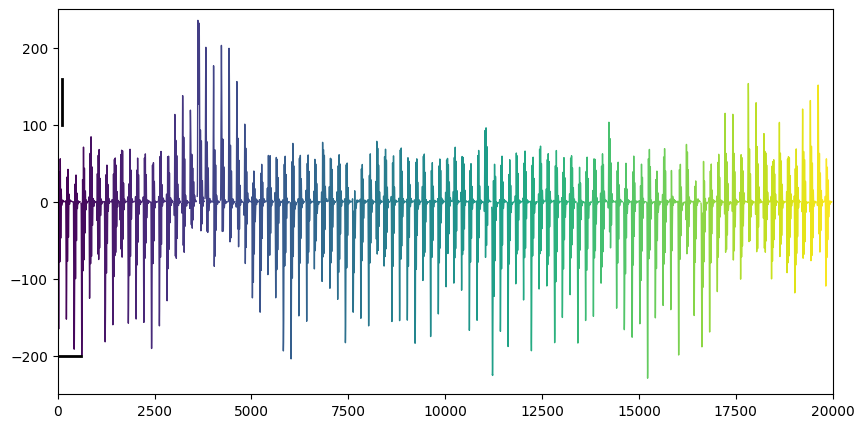

(100, 175)


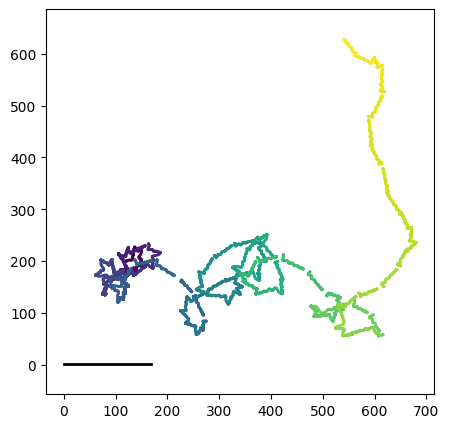

In [9]:
rec=444
mode=0
st = 0
en = 100#lengths[rec]
# print(eigfish[rec].compressed().shape)

colors_ = np.arange((en-st))
colors_ = ma.repeat(colors_[:,np.newaxis],X_head_allcond.shape[2],axis=1)

plt.figure(figsize=(10,5))
for kt in range(st,en):
    plt.plot(np.arange(200*kt,200*kt+175),rec_bout(pca_fish[rec,kt],eigvecs,data_m),c=get_colors(colors_[kt][0],plt.cm.viridis,st,en),lw=1)
plt.plot(np.arange(0,600),-200*np.ones(600),lw=2,c='k')
plt.plot(100*np.ones(60),np.arange(100,160),lw=2,c='k')
plt.ylim(-250,250)
plt.xlim(0,20000)
# plt.savefig(Fig_path + 'Dark_timeseries_eg.pdf')
plt.show()

plt.figure(figsize=(5,5))
X_toplot = X_head_allcond[rec,st:en,:,0]
Y_toplot = X_head_allcond[rec,st:en,:,1]
print(X_toplot.shape)
plt.scatter(ma.hstack(X_toplot),ma.hstack(Y_toplot),alpha=.75,c =np.arange(len(ma.hstack(Y_toplot))),cmap='viridis',s = 1.,rasterized=True)#, norm=divnorm)
plt.plot(np.arange(0,170),np.ones(170),lw=2,c='k')
plt.axis('equal')
# plt.savefig(Fig_path + 'Dark_xy_eg.pdf')
plt.show()

In [9]:
## Load symbolic sequences

path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/Zebrafish/'
f = h5py.File(path_to_filtered_data + 'microstate_labels.h5')
lengths_all = np.array(f['MetaData/lengths_data'], dtype=int)
labels_fish_allrec = ma.array(f['labels_fish'],dtype=int)
state_trajs = ma.array(f['state_trajs'])
f.close()

# lengths_all = np.load('/Users/gautam.sridhar/Documents/Repos/ZebraBouts/Datasets/Full_Data/lengths_ex2_recordings.npy')
# lengths_all = lengths

In [10]:
# recs_ = np.asarray(conditions[:,0], dtype=int)

to_mask = 1300

# maxL = np.max(lengths_all[recs_])
maxL = np.max(lengths_all)

labels_fish_allrec[labels_fish_allrec == to_mask] = ma.masked

# labels_fishrec = to_mask * ma.ones((len(recs_), maxL))
# labels_fishrec = labels_fish_allrec[recs_,:maxL+2]
# labels_fishrec = np.delete(labels_fishrec,4,0)

# labels_fishrec[labels_fishrec == to_mask] = ma.masked
labels_fish = labels_fish_allrec

# lengths_rem = np.delete(lengths_all, recs_remove)
lengths_rem = lengths_all

In [11]:
## Select Dataset
np.random.seed(42)
seeds = np.random.randint(0,10000,100)
delay_range = np.arange(1,20,1)
dt = 1
div= 463
n_modes=50
labels_all= ma.concatenate(labels_fish,axis=0)
print(labels_fish.shape)

(463, 11651)


In [12]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/Zebrafish/'
f = h5py.File(path_to_filtered_data+'distances_combined.h5','r')
Dc_q_data = np.array(f['Dc_q_data'],dtype=float)
Dc_q_eps = np.array(f['Dc_q_eps'],dtype=float)
q_range = np.array(f['q_range'],dtype=float)
f.close()

In [1]:
print(q_range)

NameError: name 'q_range' is not defined

In [13]:
# D_eps_arr = np.stack(D_eps_list,axis=0)
D_arr = Dc_q_data
Eps_arr = Dc_q_eps

In [14]:
D_ratio = Dc_q_data/(Dc_q_eps)-1
for i in range(len(D_ratio)):
    np.fill_diagonal(D_ratio[i],0)
# D_ratio = Dc_q_data-Dc_q_reg_eps

D_ratio[D_ratio<0]=0
D_int = np.trapz(D_ratio,q_range,axis=0)
np.fill_diagonal(D_int,0)

/scratch/ipykernel_3476639/2748439544.py:1: RuntimeWarning: invalid value encountered in divide
  D_ratio = Dc_q_data/(Dc_q_eps)-1


In [15]:
path_to_filtered_data

'/flash/StephensU/Gautam/HMD/Results/Zebrafish/'

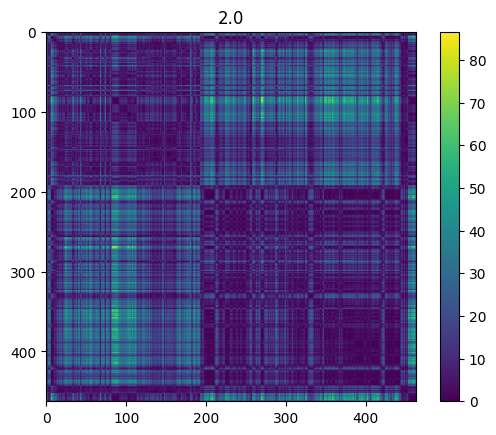

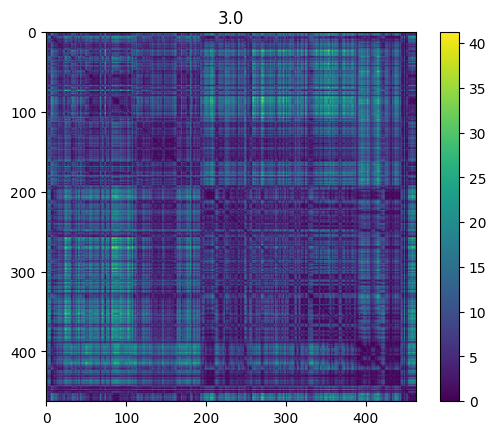

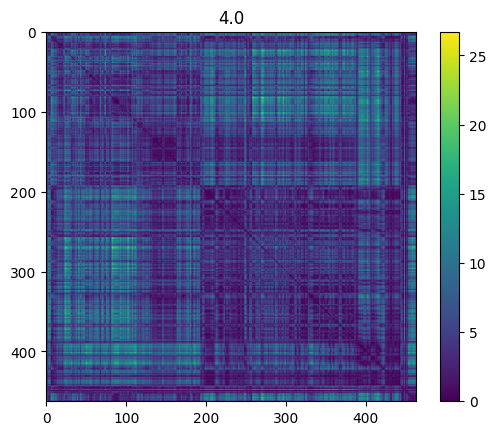

In [17]:
for i in range(3):
    plt.title(q_range[i])
    plt.imshow(D_ratio[i].data)
    plt.colorbar()
    plt.show()

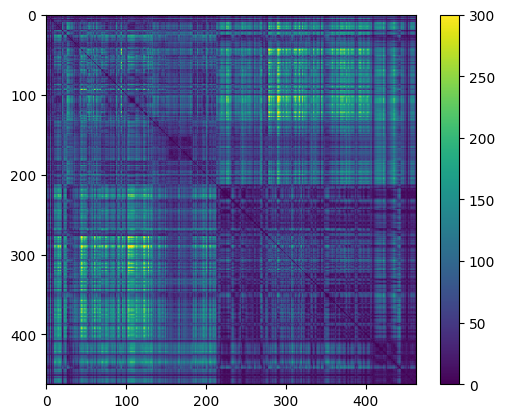

In [18]:
denoised_distmat_c = np.zeros(D_int.shape)
denoised_distmat_c[:20,:20] = D_int[443:463, 443:463]
denoised_distmat_c[:20,20:] = D_int[443:463, :-20]
denoised_distmat_c[20:,:20] = D_int[:-20, 443:463]

denoised_distmat_c[20:,20:] = D_int[:443,:][:,:443]



plt.imshow(denoised_distmat_c,vmax = 300)
plt.colorbar()
# plt.savefig(Fig_path+'D_int.pdf')

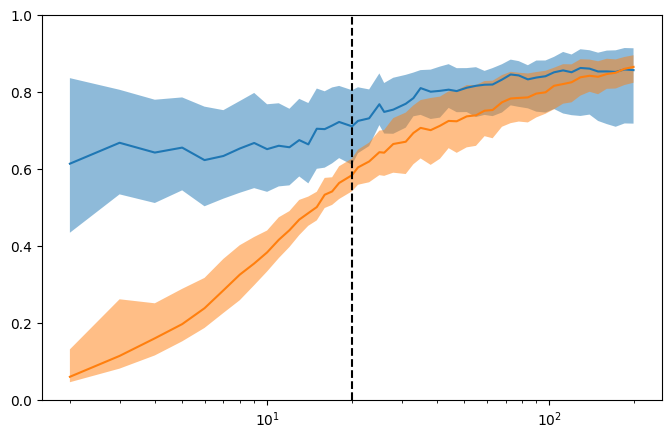

In [19]:
plt.figure(figsize=(8,5))
mean = Dc_q_data.max(axis=2).mean(axis=1)
cil = np.percentile(Dc_q_data.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Dc_q_data.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Dc_q_eps.max(axis=2).mean(axis=1)
cil = np.percentile(Dc_q_eps.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Dc_q_eps.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
plt.axvline(20,c='k',ls='--')

plt.xscale('log')
plt.ylim(0,1.0)
plt.show()

In [102]:
def diff_map_eigvals(D_int,sigma_mat):
    kern = np.exp(-D_int**2 / sigma_mat)
    qa = kern.sum(axis=0) ** -1
    Da = np.diag(qa)
    L = np.dot(Da, np.dot(kern, Da))
    M = np.dot(np.diag(np.sum(L, axis=1) ** -1), L)
    # M = op_calc.get_reversible_transition_matrix(M)
    
    diff_eig, _ =  np.linalg.eig(M)
    diff_eig[diff_eig<1e-12] = 1e-12
    sorted_indices = np.argsort(diff_eig.real)[::-1]
    diff_eig = diff_eig[sorted_indices].real
    return diff_eig[1:]

n_points = int(0.50*len(D_int))
k_sigma=50

sorted_d = np.sort(D_int, axis=1)
sigma = np.zeros(len(D_int))
for i in range(len(D_int)):
    nonzero = sorted_d[i, sorted_d[i] > 0]
    if len(nonzero) >= k_sigma:
        sigma[i] = nonzero[k_sigma - 1]
    else:
        sigma[i] = nonzero[-1] if len(nonzero) > 0 else 1.0  # fallback
        
sigma_mat = np.outer(sigma, sigma)
eigs_shuffle = np.zeros((len(seeds),20))
for s in seeds:
    print(s)
    np.random.seed(s)
    idx = np.random.choice(np.arange(0,len(D_int)),n_points,replace=False)
    eigs_shuffle[s,:] = diff_map_eigvals(D_int[idx,:][:,idx],sigma_mat[idx,:][:,idx])[:20]

var_eigs = (eigs_shuffle**2)/np.sum((eigs_shuffle**2),axis=1,keepdims=True)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


<ErrorbarContainer object of 3 artists>

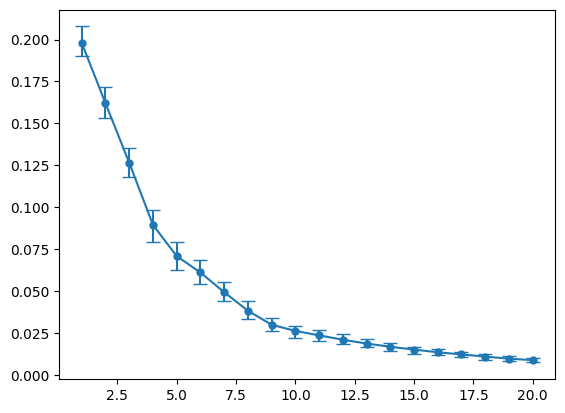

In [104]:
cil = np.nanpercentile(var_eigs[:,:20],2.5,axis=0)
ciu = np.nanpercentile(var_eigs[:,:20],97.5,axis=0)
m = np.nanmean(var_eigs[:,:20],axis=0)
# plt.plot(np.arange(14),m)
plt.errorbar(np.arange(1,21),m,[m-cil,ciu-m],capsize=5,fmt='.-',markersize=10)
# plt.savefig(Fig_path + 'eig_variance.pdf')

In [16]:
from scipy.sparse.linalg import eigs
sorted_d = np.sort(D_int, axis=1)
k=50
M = dmaps.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

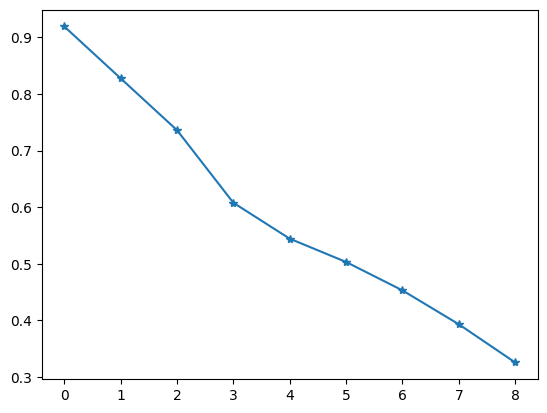

In [17]:
from scipy.sparse.linalg import eigsh
# P = L / L.sum(axis=1)[:, np.newaxis]
diff_eig, diff_ev = eigsh(M,k=10,which='LA')
diff_inv_mes = op_calc.stationary_distribution(M)
diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_eig[diff_eig<1e-12] = 0
diff_dists = diff_eig*(diff_eigvecs[:,sorted_indices].real)

plt.plot(diff_eig[1:],marker='*')
# 
# plt.axhline(ma.mean(max_eigs),c='k')
# cil = np.nanpercentile(max_eigs,2.5)
# ciu = np.nanpercentile(max_eigs,97.5)
# plt.axhspan(cil,ciu,color='k',alpha=.3)

# plt.plot(diff_eig[1:],marker='*')
# plt.axhline(0)

In [18]:
print(ecs_allcond.shape)

(463, 11651)


In [19]:
time_Bout_allcond[time_Bout_allcond == 0] = ma.masked
ecs_allcond[ecs_allcond == 100] = ma.masked

In [20]:
ecs_prop_all = []
for cf in range(463):
    ecs_prop_all.append(len(np.where(ecs_allcond[cf] == 2)[0])/lengths_all[cf])

In [21]:
diff_dists[:,2] = -1*diff_dists[:,2]

In [22]:
print(condition_labels)

['Light (5x5cm)', 'Looming(5x5cm)', 'Dark_Transitions(5x5cm)', 'Dark (5x5cm)', '3 min Light<->Dark(5x5cm)', 'Light (1x5cm)', 'Phototaxis', 'Optomotor Response (1x5cm)', 'Optokinetic Response (5x5cm)', 'Prey Capture Param. (2.5x2.5cm)', 'Prey Capture Param. RW. (2.5x2.5cm)', 'Prey Capture Rot.(2.5x2.5cm)', 'Prey capture Rot. RW. (2.5x2.5cm)', 'Light RW. (2.5x2.5cm)']


(-1.6262997282870517,
 1.3510592201338059,
 -1.6460643592745718,
 2.3537916250487707)

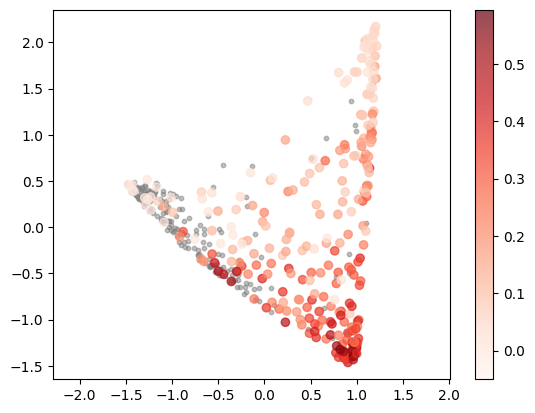

In [23]:
pc_cond_recs = np.arange(193,463)
plt.scatter(diff_dists[pc_cond_recs,1],-1*diff_dists[pc_cond_recs,2],c = np.array(ecs_prop_all)[pc_cond_recs],cmap='Reds',vmin=-0.05,zorder=10,alpha=0.7,rasterized=True)
plt.colorbar()
nonpc_cond_recs = np.arange(0,193)
plt.scatter(diff_dists[nonpc_cond_recs,1],-1*diff_dists[nonpc_cond_recs,2],c='grey',alpha=0.5,s=10,rasterized=True)
# for i in range(len(condition_labels)):
#     cond_label = condition_labels[i]
#     cond_recs = np.where(conditions[:,1] == cond_label)[0]
#     plt.scatter(-1*ma.median(diff_dists[cond_recs,1]),ma.median(diff_dists[cond_recs,2]),marker='${}$'.format(i),s=200,zorder=20)
plt.axis('equal')
# plt.savefig(Fig_path + 'Zebrafish_diffmap.pdf')

(100, 5000, 2)
(100, 5000, 2)
(100, 5000, 2)


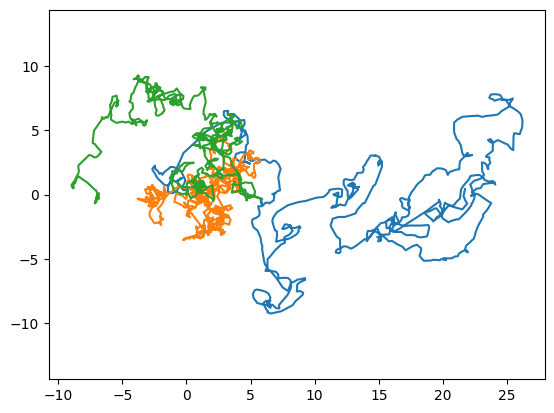

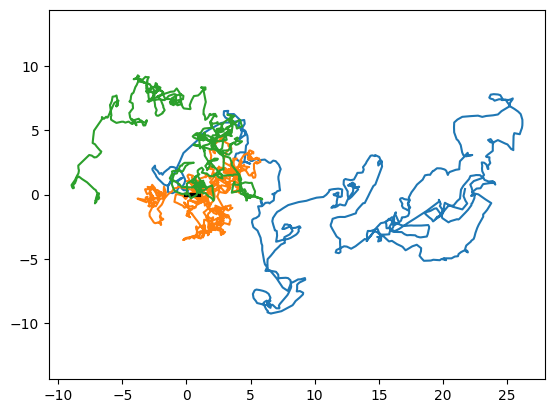

In [5]:
idx=99

for clus in np.arange(1,4):
    f = h5py.File(path_to_filtered_data + 'sims/sims_lensim_5000_group_{}_{}.h5'.format(clus,idx),'r')
    X_sims = np.array(f['sims_gs_X'])
    print(X_sims.shape)
    f.close()
    plt.plot(X_sims[0][:1000,0],X_sims[0][:1000,1],c='C{}'.format(clus-1))
    plt.axis('equal')
plt.show()

In [ ]:
# conds_to_comp = [[11],[12]]
# cond_recs1 = []
# cond_recs2 = []
# for c in conds_to_comp[0]:
#     cond_recs1.append(np.where(conditions[:,1] == condition_labels[c])[0])
# cond_recs1 = np.hstack(cond_recs1)

# for c in conds_to_comp[1]:
#     cond_recs2.append(np.where(conditions[:,1] == condition_labels[c])[0])
# cond_recs2 = np.hstack(cond_recs2)


# D_here = Dc_q_data[:,cond_recs1,:][:,:,cond_recs2]
# Eps_here = Dc_q_eps[:,cond_recs1,:][:,:,cond_recs2]


# plt.figure(figsize=(8,5))
# mean = D_here.max(axis=2).mean(axis=1)
# # mean= np.median(Dc_q_data.max(axis=2),axis=1)
# cil = np.percentile(D_here.max(axis=2),2.5,axis=1)
# ciu =  np.percentile(D_here.max(axis=2),97.5,axis=1)
# plt.plot(q_range,mean,label='data')
# plt.fill_between(q_range,cil,ciu,alpha=.5)

# mean = Eps_here.max(axis=2).mean(axis=1)
# # mean = np.median(Dc_q_eps.max(axis=2),axis=1)
# cil = np.percentile(Eps_here.max(axis=2),2.5,axis=1)
# ciu =  np.percentile(Eps_here.max(axis=2),97.5,axis=1)
# plt.plot(q_range,mean,label='eps')
# plt.fill_between(q_range,cil,ciu,alpha=.5)
# # plt.axvline(20,c='k',ls='--')
# # plt.axvline(3,c='k',ls='--')
# # plt.axvline(12,c='k',ls='--')
# # plt.axvline(91,c='k',ls='--')
# plt.xscale('log')
# # plt.yscale('log')
# # plt.xlabel('q')
# # plt.ylabel('<D>')
# plt.ylim(0,1.0)
# # plt.savefig(Fig_path+'/dist_v_eps_light_sensory.pdf')
# plt.show()

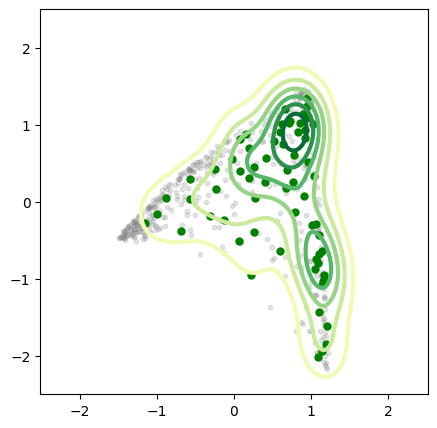

In [77]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
from scipy.stats import gaussian_kde
cmaps = ['YlGn']
colors_ = ['Green']
nonpc_cond_recs = np.arange(0,193)

plt.scatter(diff_dists[:,1],diff_dists[:,2],c='grey',alpha=0.2,s=10)

for i,cond in enumerate([9]):
    idx = np.where(conditions[:,1] == condition_labels[cond])[0]
    plt.scatter(diff_dists[idx,1],diff_dists[idx,2],c=colors_[i],alpha=1,s=25)
    values = diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.4)
    X,Y = np.meshgrid(np.linspace(-2.5,2.5,200),np.linspace(-2.5,2.5,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = [np.median(diff_dists[idx,1],axis=0),np.median(diff_dists[idx,2],axis=0)]
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities_pcrotrw.pdf')
plt.show()

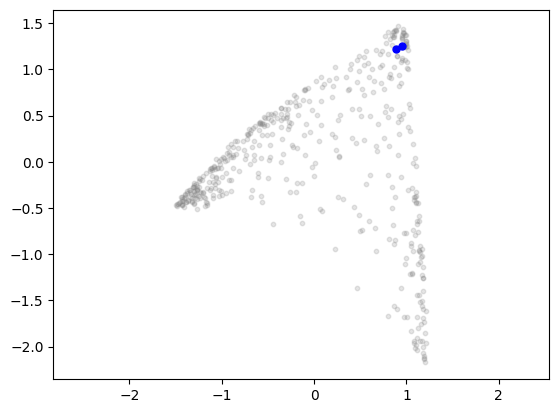

In [80]:
fig, ax = plt.subplots(1,1)
from scipy.stats import gaussian_kde
cmaps = ['PuBu']
colors_ = ['Blue']
nonpc_cond_recs = np.arange(0,193)

plt.scatter(diff_dists[:,1],diff_dists[:,2],c='grey',alpha=0.2,s=10)

for i,cond in enumerate([10]):
    idx = np.where(conditions[:,1] == condition_labels[cond])[0]
    for k in idx:
        if k in [idx[0] + 49,idx[0] + 50]:
            plt.scatter(diff_dists[k,1],diff_dists[k,2],c=colors_[i],alpha=1,s=25)
    values = diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.25)
    X,Y = np.meshgrid(np.linspace(-2,2,200),np.linspace(-2,2,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    # img = np.reshape(kernel(positions).T, X.shape)
    # plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = [np.median(diff_dists[idx,1],axis=0),np.median(diff_dists[idx,2],axis=0)]
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities_pcparamrw.pdf')
plt.show()

In [70]:
np.var(diff_dists[idx_rep,:2])

0.3032224728971153

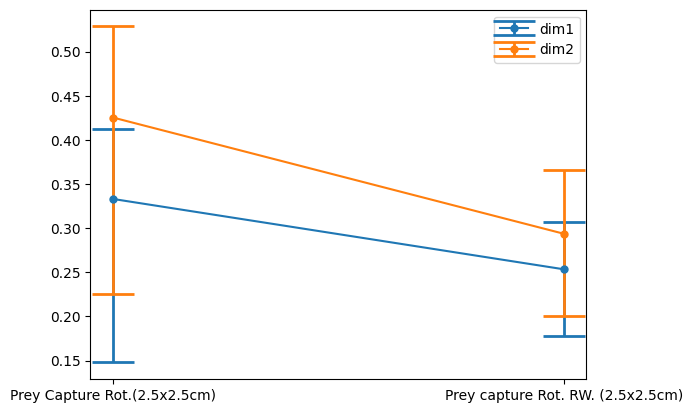

In [69]:
cond1= 11
idx = np.where(conditions[:,1] == condition_labels[cond1])[0]
var_dim1_cond1= []
var_dim2_cond1= []
for s in range(100):
    np.random.seed(s)
    idx_rep = np.random.choice(idx, replace=False, size=int(len(idx)*0.8))
    var_dim1_cond1.append(np.var(diff_dists[idx_rep,1]))
    var_dim2_cond1.append(np.var(diff_dists[idx_rep,2]))

cond2 = 12
idx = np.where(conditions[:,1] == condition_labels[cond2])[0]

var_dim1_cond2= []
var_dim2_cond2= []
for s in range(100):
    np.random.seed(s)
    idx_rep = np.random.choice(idx, replace=False, size=int(len(idx)*0.8))
    var_dim1_cond2.append(np.var(diff_dists[idx_rep,1]))
    var_dim2_cond2.append(np.var(diff_dists[idx_rep,2]))

ms = np.array([np.mean(var_dim1_cond1),np.mean(var_dim1_cond2)])
cils = np.array([np.nanpercentile(var_dim1_cond1,2.5),np.nanpercentile(var_dim1_cond2,2.5)])
cius = np.array([np.nanpercentile(var_dim1_cond1,97.5),np.nanpercentile(var_dim1_cond2,97.5)])

plt.errorbar(np.arange(2),ms, [ms- cils,cius-ms],
                ms=10,fmt='.-', capsize=15,capthick=2, elinewidth = 2,label='dim1')


ms = np.array([np.mean(var_dim2_cond1),np.mean(var_dim2_cond2)])
cils = np.array([np.nanpercentile(var_dim2_cond1,2.5),np.nanpercentile(var_dim2_cond2,2.5)])
cius = np.array([np.nanpercentile(var_dim2_cond1,97.5),np.nanpercentile(var_dim2_cond2,97.5)])

plt.errorbar(np.arange(2),ms, [ms- cils,cius-ms],
                ms=10,fmt='.-', capsize=15,capthick=2, elinewidth = 2,label='dim2')

plt.xticks([0,1],[condition_labels[cond1],condition_labels[cond2]])

plt.legend()


In [ ]:
cond1= 11
idx = np.where(conditions[:,1] == condition_labels[cond1])[0]
var_dim1_cond1= []
var_dim2_cond1= []
for s in range(100):
    np.random.seed(s)
    idx_rep = np.random.choice(idx, replace=False, size=int(len(idx)*0.8))
    var_dim1_cond1.append(np.var(diff_dists[idx_rep,1]))
    var_dim2_cond1.append(np.var(diff_dists[idx_rep,2]))

cond2 = 12
idx = np.where(conditions[:,1] == condition_labels[cond2])[0]

var_dim1_cond2= []
var_dim2_cond2= []
for s in range(100):
    np.random.seed(s)
    idx_rep = np.random.choice(idx, replace=False, size=int(len(idx)*0.8))
    var_dim1_cond2.append(np.var(diff_dists[idx_rep,1]))
    var_dim2_cond2.append(np.var(diff_dists[idx_rep,2]))

In [25]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/Zebrafish/'
f =  h5py.File(path_to_filtered_data + '/cg_labels_tree_minrho.h5')
cg_labels_tree = np.array(f['labels_tree'],dtype=int)
print(f.keys())
f.close()

<KeysViewHDF5 ['labels_tree']>


In [28]:
path_to_filtered_data = '/bucket/StephensU/Gautam/HMD/Results/Zebrafish/'
P_ensemble = np.load(path_to_filtered_data + 'P_ensemble_resampled.npy')

In [29]:
import deeptime.markov.tools.estimation as msm_estimation
delay = 3
dt = 1
print(delay)
# lcs_ensemble,P_ensemble = op_calc.transition_matrix(labels_all,delay,return_connected=True)
lcs_ensemble = msm_estimation.largest_connected_set(P_ensemble)
inv_measure = op_calc.stationary_distribution(P_ensemble)
final_labels = op_calc.get_connected_labels(labels_all,lcs_ensemble)

3


In [30]:
ha = cg_labels_tree[18]
cluster_traj_all = ma.copy(final_labels)
cluster_traj_all[~final_labels.mask] = ma.array(ha)[final_labels[~final_labels.mask]]
cluster_traj_all[final_labels.mask] = ma.masked

cluster_fish = cluster_traj_all.reshape(labels_fish.shape[0],labels_fish.shape[1])
cluster_fish_mask = cluster_fish.mask

In [31]:
print(condition_labels)

['Light (5x5cm)', 'Looming(5x5cm)', 'Dark_Transitions(5x5cm)', 'Dark (5x5cm)', '3 min Light<->Dark(5x5cm)', 'Light (1x5cm)', 'Phototaxis', 'Optomotor Response (1x5cm)', 'Optokinetic Response (5x5cm)', 'Prey Capture Param. (2.5x2.5cm)', 'Prey Capture Param. RW. (2.5x2.5cm)', 'Prey Capture Rot.(2.5x2.5cm)', 'Prey capture Rot. RW. (2.5x2.5cm)', 'Light RW. (2.5x2.5cm)']


In [32]:
conds_to_comp = [[9],[10]]
cond_recs1 = []
cond_recs2 = []
for c in conds_to_comp[0]:
    print(condition_labels[c])
    cond_recs1.append(np.where(conditions[:,1] == condition_labels[c])[0])
cond_recs1 = np.hstack(cond_recs1)

for c in conds_to_comp[1]:
    print(condition_labels[c])
    cond_recs2.append(np.where(conditions[:,1] == condition_labels[c])[0])
cond_recs2 = np.hstack(cond_recs2)

P_cond_1 = np.zeros((len(cond_recs1),len(np.unique(ha)),len(np.unique(ha))))
im_2c_1= []
for k,idx in enumerate(cond_recs1):
    lcs_spec,P_spec = op_calc.transition_matrix([cluster_fish[idx]],delay=3, return_connected=True)
    for i,l in enumerate(lcs_spec):
        P_cond_1[k, l,lcs_spec] = P_spec.todense()[i]
for i in range(len(P_cond_1)):
    im_2c_1.append(P_cond_1[i,:,:].sum(axis=0)/P_cond_1[i,:,:].sum())

im_2c_1 = np.vstack(im_2c_1)

P_cond_1 = np.mean(P_cond_1,axis=0)

P_cond_2 = np.zeros((len(cond_recs2),len(np.unique(ha)),len(np.unique(ha))))
for k,idx in enumerate(cond_recs2):
    lcs_spec,P_spec = op_calc.transition_matrix([cluster_fish[idx]],delay=3, return_connected=True)
    for i,l in enumerate(lcs_spec):
        P_cond_2[k, l,lcs_spec] = P_spec.todense()[i]

im_2c_2= []

for i in range(len(P_cond_2)):
    im_2c_2.append(P_cond_2[i,:,:].sum(axis=0)/P_cond_2[i,:,:].sum())

im_2c_2 = np.vstack(im_2c_2)

P_cond_2 = np.mean(P_cond_2,axis=0)

Prey Capture Param. (2.5x2.5cm)
Prey Capture Param. RW. (2.5x2.5cm)


In [33]:
log_fold_changes = []
for i in range(len(im_2c_2)):
    for j in range(len(im_2c_1)):
        log_fold_change = ma.array(ma.log2(im_2c_2[i]/(im_2c_1[j])))
        log_fold_change[np.isinf(log_fold_change.data)] = ma.masked
        log_fold_changes.append(log_fold_change)

/scratch/ipykernel_3476639/1935600328.py:4: RuntimeWarning: divide by zero encountered in divide
  log_fold_change = ma.array(ma.log2(im_2c_2[i]/(im_2c_1[j])))
/scratch/ipykernel_3476639/1935600328.py:4: RuntimeWarning: invalid value encountered in divide
  log_fold_change = ma.array(ma.log2(im_2c_2[i]/(im_2c_1[j])))


In [34]:
log_fold_changes = ma.vstack(log_fold_changes)

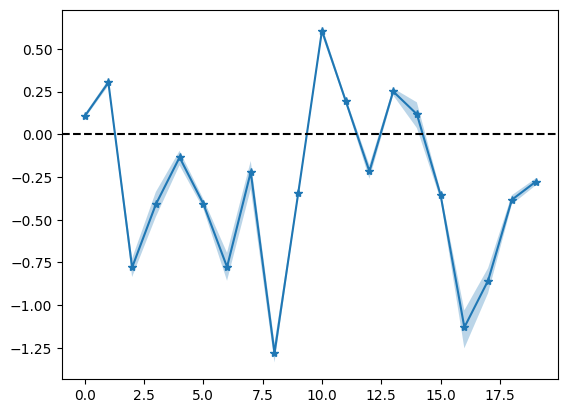

In [35]:
m, cil, ciu = stats.bootstrap(log_fold_changes,n_times=100)
plt.plot(np.arange(len(m)),m,marker='*')
plt.fill_between(np.arange(len(m)), cil, ciu,alpha=0.3)
plt.axhline(0,c='k',ls='--')

In [36]:
from scipy.stats import ranksums
p_vals = []
for i in range(20):
    p_vals.append(ranksums(im_2c_1[:,i], im_2c_2[:,i])[1])

([<matplotlib.axis.YTick at 0x7fcfd70ae820>,
 [Text(0, 0, '8'),
  Text(0, 1, '17'),
  Text(0, 2, '2'),
  Text(0, 3, '5'),
  Text(0, 4, '18'),
  Text(0, 5, '15'),
  Text(0, 6, '9'),
  Text(0, 7, '19'),
  Text(0, 8, '13'),
  Text(0, 9, '1'),
  Text(0, 10, '10')])

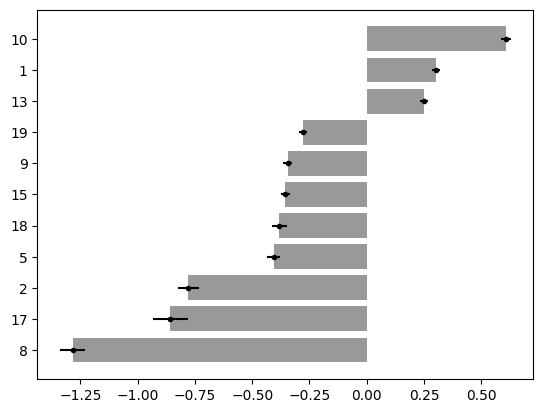

In [37]:
idx_to_plot = np.where(np.array(p_vals)<0.01)[0]
m, cil, ciu = stats.bootstrap(log_fold_changes,n_times=100)

sort_idx = np.argsort(m[idx_to_plot])
idx_to_plot = idx_to_plot[sort_idx]
plt.barh(np.arange(len(idx_to_plot)),m[idx_to_plot],alpha=0.4,color='k')
# plt.fill_between(np.arange(len(idx_to_plot)), cil[idx_to_plot], ciu[idx_to_plot],alpha=0.3)
plt.errorbar(m[idx_to_plot],np.arange(len(idx_to_plot)),yerr=None,xerr=[m[idx_to_plot]-cil[idx_to_plot], ciu[idx_to_plot]-m[idx_to_plot]],fmt='.',color='k')
plt.yticks(ticks =np.arange(len(idx_to_plot)),labels= idx_to_plot)
# plt.axvline(0,c='k',ls='--')
# plt.axvline(1,c='r',ls='--')
# plt.axvline(2,c='r',ls='--')
# plt.axvline(-1,c='r',ls='--')
# plt.axvline(3,c='r',ls='--')
# plt.savefig(Fig_path+'/LFC_rotn_rw.pdf')

In [115]:
state = 10
lifetimes_cond_recs = [[],[]]
for i,c in enumerate([9,10]):
    print(c)
    cond = np.where(conditions[:,1] == condition_labels[c])[0]
    cluster_recs_condition = cluster_fish[cond,:]
    ls = []
    for cf in range(cluster_recs_condition.shape[0]):
        data_lifetimes, state_labels = stats.state_lifetime(cluster_recs_condition[cf],dt)
        lifetimes_cond_recs[i].append(data_lifetimes[state])

9
10


In [116]:
ms = [[],[]]
cils = [[],[]]
cius = [[],[]]

for i in range(2):
    m = []
    for j in range(len(lifetimes_cond_recs[i])):
        print(lifetimes_cond_recs[i][j])
        m.append(np.mean(lifetimes_cond_recs[i][j]))
    # print(m)
    ms[i] = np.mean(m)
    cils[i] = np.nanpercentile(m,2.5)
    cius[i] = np.nanpercentile(m,97.5)

[ 1  1  1  1  1  1  1  8  2  1  3  1  1  4  2  1  3  1  1  1  2  2  2  3
  1  2  1  4  1  1  1  5  1  4  1  1  1  1  1  1  1  3  1  7  2  1  1  2
  2  1  1  6  2  1  5  2  3  1  2  1  1  1  1  1  1  1  1  1  3  1  1  1
  3  3  1  6  1  2  3  1  4  1  1  3  1  1  1  1  6  1  3  1  1  1  1  1
  1  1  5  3  5  3  1  5  2  2  1  2  5  4  1  1  1  3 11  2  2  1  1  2
  2  4  2  1  2  1  1  9  1  3  1  2  1  1  3  1  1  2  2  1  2  3  1  1
  6  1  2  2  1  1  1  1  3  2  1  2  1  1  2  1  1  4  1  6  5  1  1  1
  1]
[2 2 1 3 3 4 1 1 1 2 1 5 2 3 2 1 1 1 3 1 2 1 1 3 1 4 1 1 1 9 1 1 3 1 2 1 1
 4 2 1 3 1 1 1 1 1 1 3 1 4 1 1 1 1 1 1 6 3 1 1 1 8 1 2 1 2 2 1 3 1 1 1 2 2
 1 2 1 1 5 1 3 1 2 2 5 1 1 4 1 1 1 1 1 1 1 1 1 2]
[ 1  1  1  1  3  1  3  3  3  1  3  2  1  1  1  1  4  1  2  1  1  4  2  1
  1  2  1  1  1  1  1  1  1  1  4  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 11  2  1  1  1  1  1  3  1  1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 4 1 1 1 2 1 1 2 4 1 1 1 1 2 1 1 1 1 1
 2 3 1 2 1 1 1 2 1 

In [117]:
y_errorbar_metastate, x_all_metastate, mean_lifetimes = stats.state_lifetimes_stats(lifetimes_cond_recs, n_states=2)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276


0
1


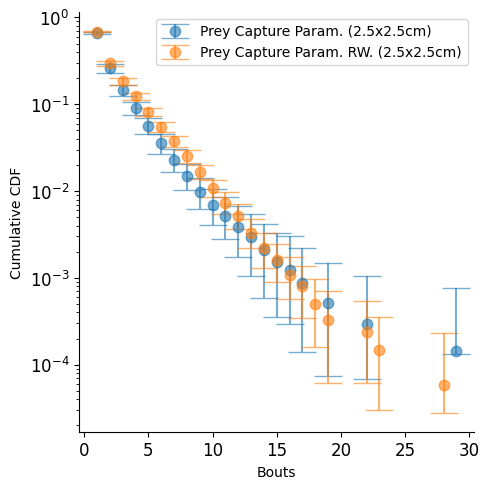

In [122]:
fig,ax = plt.subplots(1,1, figsize=(5,5))
t0,tf=1,50
xrange = np.linspace(t0,tf,160)
for ms in [0,1]:
    print(ms)

    mean = y_errorbar_metastate[ms][:-1,0]
    cil = y_errorbar_metastate[ms][:-1,1]
    ciu = y_errorbar_metastate[ms][:-1,2]
    
    ax.errorbar(x_all_metastate[ms][:-1], mean,[mean-cil, ciu - mean],ms=15 ,fmt='.', capsize=10, alpha=0.6, label=condition_labels[ms+9])
#     ax.fill_between(x_all_metastate[ms][:-1], y_errorbar_metastate[ms][:-1,1], y_errorbar_metastate[ms][:-1,2], alpha=0.2, color=st_colors[ms])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yscale('log')
ax.set_xlabel('Bouts')
ax.set_ylabel('Cumulative CDF')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# ax.set_xlim(-1,400)
# ax.set_ylim(1e-4,1)
plt.tight_layout()
plt.legend()
# plt.savefig('/Users/gautam.sridhar/Documents/ZENITH/Figures/Suppl2/WC_dt.pdf')

In [100]:
class_names = np.array(['Short CS','Long CS','BS','O_bend','J turn','SLC','Slow1','RT',
               'Slow2','LLC','AS','SAT','HAT'])

In [101]:
bouttypes[bouttypes == 15.] = ma.masked
bout_props_recs = np.zeros((len(bouttypes), len(np.unique(ha)),class_names.shape[0]))

for ms in np.unique(cluster_traj_all.compressed()):
    print(ms)
    for recn in range(cluster_fish.shape[0]):
        sel = cluster_fish[recn] == ms
        segments = np.where(np.abs(np.diff(np.concatenate([[False], sel, [False]]))))[0].reshape(-1, 2)
        for segment in segments:
            t0,tf = segment
            bouts = bouttypes[recn,t0:tf].astype(int)
            for b in bouts:
                bout_props_recs[recn,ms,b-1] += 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [102]:
print(bout_props_recs[0].shape)

(20, 13)


In [103]:
ms=len(np.unique(ha))
state_rats = ma.zeros((len(bouttypes),class_names.shape[0], ms))
for i in range(len(bouttypes)):
#     print(i,bout_props_recs[i])
    # state_rats[i,:,:] = (bout_props_recs[i]/bout_props_recs[i].sum(axis=0)).T
    state_rats[i,:,:] = ((bout_props_recs[i]).T/bout_props_recs[i].sum(axis=1))

nanidx = np.where(np.isnan(state_rats))

state_rats[nanidx[0],nanidx[1],nanidx[2]] = 0
state_rats[nanidx[0],nanidx[1],nanidx[2]] = ma.masked

/scratch/ipykernel_3476639/3276136493.py:6: RuntimeWarning: invalid value encountered in divide
  state_rats[i,:,:] = ((bout_props_recs[i]).T/bout_props_recs[i].sum(axis=1))


In [104]:
st_mean = []
st_ciu = []
st_cil = []
for ms in np.unique(ha):
    print(ms)
    m,cil, ciu = stats.bootstrap(state_rats[:,:,ms],n_times = 100)
    st_mean.append(m)
    st_ciu.append(ciu)
    st_cil.append(cil)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [105]:
print(class_names)

['Short CS' 'Long CS' 'BS' 'O_bend' 'J turn' 'SLC' 'Slow1' 'RT' 'Slow2'
 'LLC' 'AS' 'SAT' 'HAT']


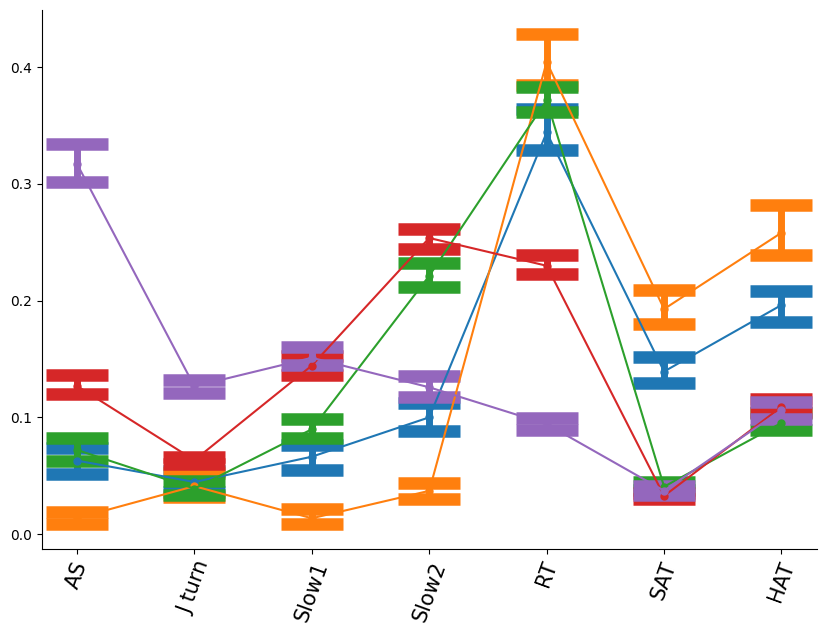

In [106]:
fig, ax = plt.subplots(1,1,figsize=(10.,7))
# colors_ = plt.cm.viridis(np.linspace(0,1.0,len(np.unique(ha))))
# state_rats = (bout_props_recs[5].T)/bout_props_recs[5].sum(axis=1)

sort_idx = [10,4,6,8,7,11,12]
# np.arange(13)

for ms in [8,17,2,1,10]:
    # ax.plot(np.arange(len(sort_idx)),st_mean[ms][sort_idx], lw = 10, alpha=0.8)
    ax.errorbar(np.arange(len(sort_idx)),st_mean[ms][sort_idx], [st_mean[ms][sort_idx] - st_cil[ms][sort_idx], st_ciu[ms][sort_idx] - st_mean[ms][sort_idx]], 
                ms=10,fmt='.-', capsize=22,capthick=9, elinewidth = 5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_xlabel('Bout types',fontsize=40)
# ax.set_ylabel('Probability in trajectory',fontsize=40)
ax.set_xticks(np.arange(len(sort_idx)))
# ax.axhline(1/50)
# ax.set_ylim(0,0.4)
ax.set_xticklabels(class_names[sort_idx],fontsize=15, rotation=70)
# plt.ytick_labels([])
# plt.xtick_labels([])
# ax.legend(fontsize=30)
# plt.savefig(Fig_path+'bouttypes_pcparamn_v_rw.pdf')
plt.show()
